In [1]:
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix
from datetime import datetime
from typing import List
from matplotlib import pyplot as plt
from matplotlib.axes import Axes

import freeze_thaw.combine_dfs as combine_dfs
from freeze_thaw.config import config as c
from freeze_thaw.config import StationName
from freeze_thaw.data_preparation.general import filter_df

# Assess Methodology

A key assumption in this project is that a single point measurement from an ISMN station can be used to benchmark an area measurement from space-based sensors. This may be a massive leap since the ASCAT and ERA5 measurements cover areas over 100 km$^2$. The goal of this notebook is to compare the ERA5 and ISMN soil temperature measurements to understand the difference between the two methods.

---

## Table of Contents

1. **Setup**
    - *1.1 Variables*
    - *1.2 Functions*
2. **ISMN Stations**
    - *2.1 Aberdeen-35-WNW*
    - *2.2 Jamestown-38-WSW*
    - *2.3 Gobblers Knob*
    - *2.4 Nenana*
    - *2.5 L23*
    - *2.6 L38*
    - *2.7 NST-07*
    - *2.8 NST-09*
    - *2.9 SOD012*
    - *2.10 SOD103*

---

## 1. Setup

### 1.1 Variables

In [ ]:
start_date = datetime(2015, 1, 1)
end_date = datetime(2016, 1, 1)

### 1.2 Functions

In [2]:
def create_cm_df(df: pd.DataFrame, classes: List[str]) -> pd.DataFrame:
    """
    Output sklearn confusion matrix.
    :param df: cleaned and combined data df with "pred" and "class" columns
    :param classes: class labels
    :return: sklearn confusion matrix in the form of a df
    """
    if not {'class', 'pred'}.issubset(df.columns):
        raise ValueError("df must contain 'class' and 'pred' columns")
    if len(classes) != len(df['class'].unique()):
        raise ValueError("classes and df['class'].unique() must have same length")

    cm = confusion_matrix(df['class'], df['pred'], labels=classes)
    cm_df = pd.DataFrame(cm, index=c.CLASSES, columns=c.CLASSES)

    return cm_df

def plot_temp_labels(df: pd.DataFrame, name: str, start: datetime, end: datetime) -> Axes:
    """
    Plots scatterplot of ERA5 stl1 vs time with datapoints colored by class label according to ISMN data.
    :param df: cleaned and combined data df
    :param name: station name
    :param start: naive datetime.datetime object (inclusive)
    :param end: naive datetime.datetime object (inclusive)
    :return: matplotlib Axes object
    """
    if not {'class', 'stl1'}.issubset(df.columns):
        raise ValueError("df must contain 'class' and 'stl1' columns")
    if not df.index.inferred_type == "datetime64":
        raise ValueError("df index inferred_type must be datetime64")

    df_copy = df.copy()
    df_copy = filter_df(df_copy, start, end)

    palette = {
        c.CLASSES[0]: "tab:blue",
        c.CLASSES[1]: "tab:brown",
        c.CLASSES[2]: "tab:green",
    }

    ax = sns.scatterplot(data=df_copy, x=df_copy.index.name, y='stl1',
                         hue='class', palette=palette
                         )
    ax.set_title(name)
    ax.set_ylabel("ERA5 stl1 (\u00B0C)")
    ax.set_xlabel("Timestamp")

    return ax

def plot_temp_differences(df: pd.DataFrame, name: str, start: datetime, end: datetime) -> tuple[Axes, Axes]:
    """
    Creates two plots. The first is a line plot of both the measured soil temperatures according to both methods.
    The second plot is a line plot that shows the difference between the ISMN and ERA5 soil temperatures.
    :param df: cleaned and combined data df
    :param name: station name
    :param start: naive datetime.datetime object (inclusive)
    :param end: naive datetime.datetime object (inclusive)
    :return: two matplotlib Axes objects
    """

    if not {'soil_temp', 'stl1'}.issubset(df.columns):
        raise ValueError("df must contain 'soil_temp' and 'stl1' columns")
    if not df.index.inferred_type == "datetime64":
        raise ValueError("df index inferred_type must be datetime64")

    df_copy = df.copy()
    df_copy = filter_df(df_copy, start, end)

    diff = df_copy["soil_temp"] - df_copy["stl1"]

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(12, 7),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}
    )

    # Top panel
    ax1.plot(df_copy.index, df_copy["stl1"], label="ERA5")
    ax1.plot(df_copy.index, df_copy["soil_temp"], label="ISMN")
    ax1.legend()
    ax1.set_title(name)
    ax1.set_ylabel("Temperature (\u00B0C)")
    ax1.grid(alpha=0.3)

    # Bottom panel
    ax2.plot(df_copy.index, diff, color="tab:red")
    ax2.axhline(0, color="black", ls="--", lw=1)
    ax2.set_ylabel("Difference (ISMN-ERA5)")
    ax2.set_xlabel("Timestamp")
    ax2.grid(alpha=0.3)

    return ax1, ax2

## 2. ISMN Stations

### 2.1 Aberdeen-35-WNW

In [4]:
_, aberdeen_era5_df = combine_dfs.main(StationName.ABERDEEN, c.CLEANED_DATA_PATH)
aberdeen_era5_df = aberdeen_era5_df.dropna()

create_cm_df(aberdeen_era5_df, c.CLASSES)

,frozen,transition,thawed
frozen,1871,286,4
transition,1570,831,429
thawed,363,355,8798


<Axes: title={'center': 'Aberdeen-35-WNW'}, xlabel='Timestamp', ylabel='ERA5 stl1 (°C)'>

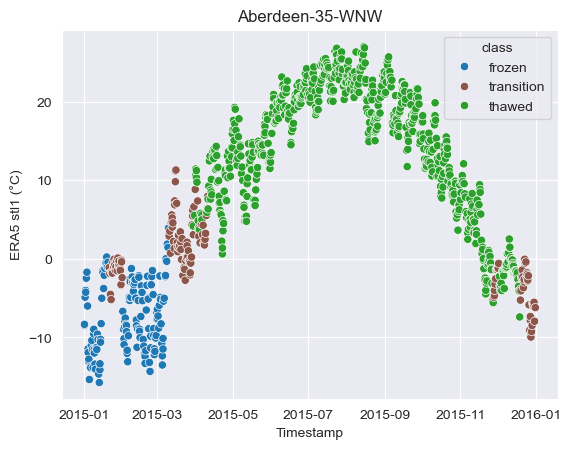

In [5]:
plot_temp_labels(aberdeen_era5_df, StationName.ABERDEEN, start_date, end_date)

(<Axes: title={'center': 'Aberdeen-35-WNW'}, ylabel='Temperature (°C)'>,
 <Axes: xlabel='Timestamp', ylabel='Difference (ISMN-ERA5)'>)

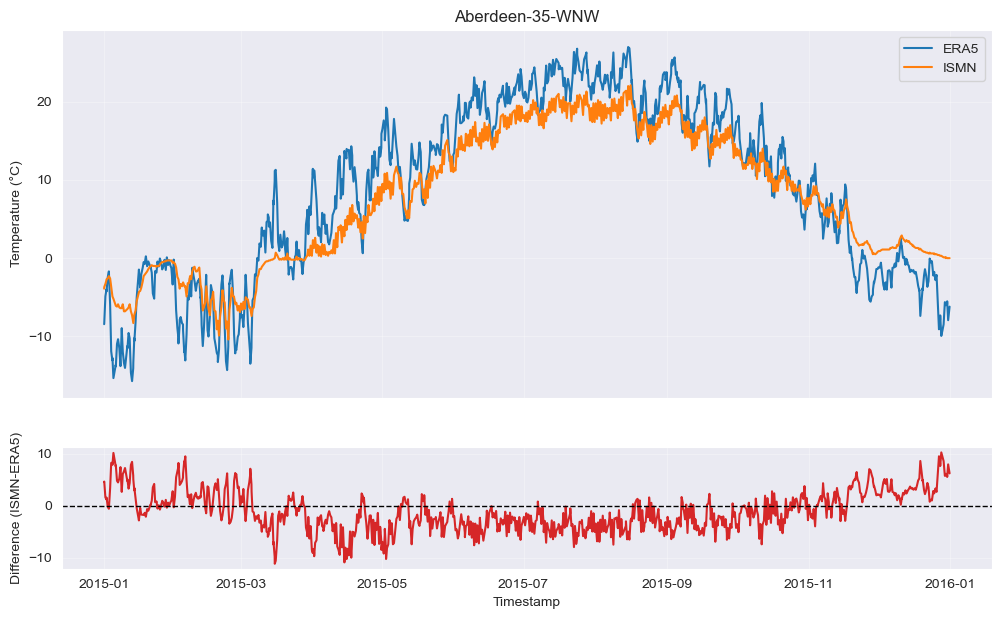

In [6]:
plot_temp_differences(aberdeen_era5_df, StationName.ABERDEEN, start_date, end_date)

### 2.2 Jamestown-38-WSW

In [7]:
_, jamestown_era5_df = combine_dfs.main(StationName.JAMESTOWN, c.CLEANED_DATA_PATH)
jamestown_era5_df = jamestown_era5_df.dropna()

create_cm_df(jamestown_era5_df, c.CLASSES)

,frozen,transition,thawed
frozen,2022,454,13
transition,1440,666,491
thawed,375,328,8368


<Axes: title={'center': 'Jamestown-38-WSW'}, xlabel='Timestamp', ylabel='ERA5 stl1 (°C)'>

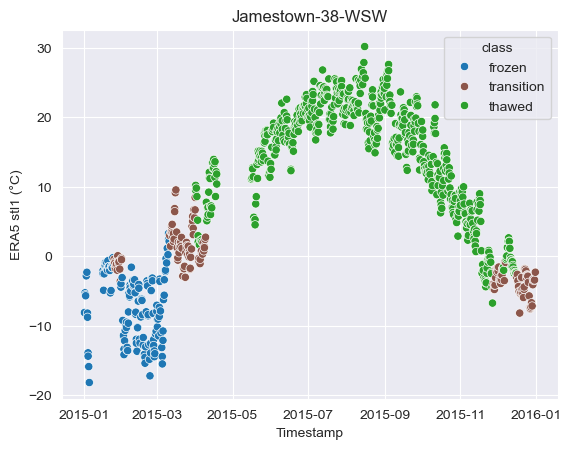

In [8]:
plot_temp_labels(jamestown_era5_df, StationName.JAMESTOWN, start_date, end_date)

(<Axes: title={'center': 'Jamestown-38-WSW'}, ylabel='Temperature (°C)'>,
 <Axes: xlabel='Timestamp', ylabel='Difference (ISMN-ERA5)'>)

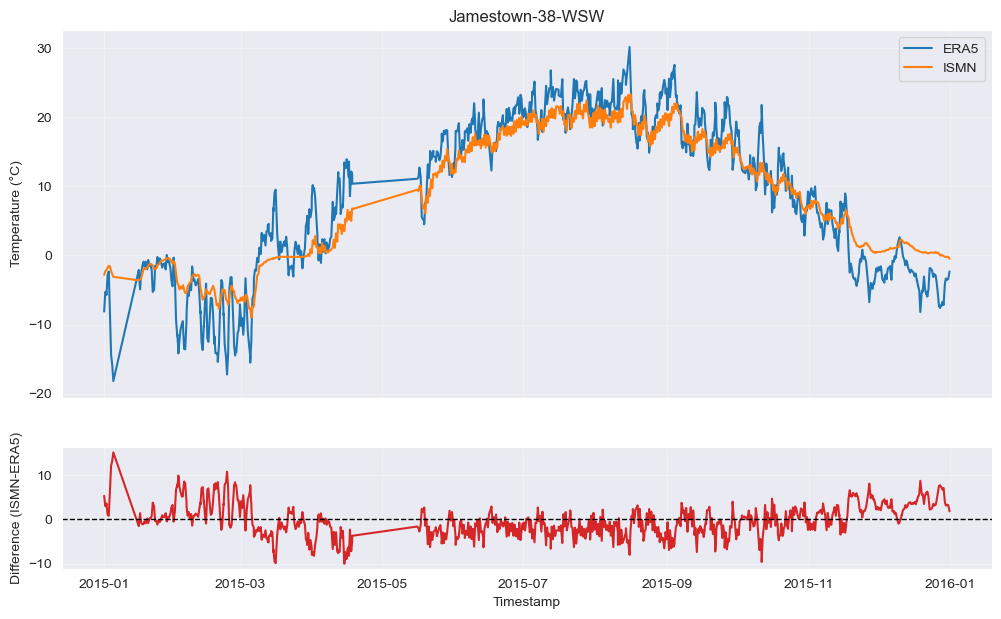

In [9]:
plot_temp_differences(jamestown_era5_df, StationName.JAMESTOWN, start_date, end_date)

### 2.3 Gobblers Knob

In [10]:
_, gobblers_knob_era5_df = combine_dfs.main(StationName.GOBBLERS_KNOB, c.CLEANED_DATA_PATH)
gobblers_knob_era5_df = gobblers_knob_era5_df.dropna()

create_cm_df(gobblers_knob_era5_df, c.CLASSES)

,frozen,transition,thawed
frozen,13307,2320,4
transition,1755,1957,634
thawed,40,244,11472


<Axes: title={'center': 'GobblersKnob'}, xlabel='Timestamp', ylabel='ERA5 stl1 (°C)'>

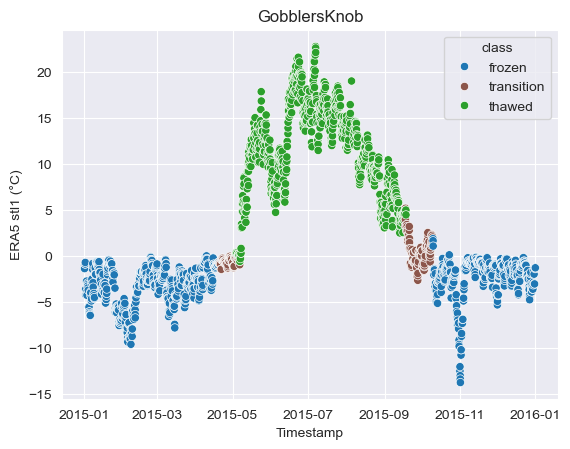

In [11]:
plot_temp_labels(gobblers_knob_era5_df, StationName.GOBBLERS_KNOB, start_date, end_date)

(<Axes: title={'center': 'GobblersKnob'}, ylabel='Temperature (°C)'>,
 <Axes: xlabel='Timestamp', ylabel='Difference (ISMN-ERA5)'>)

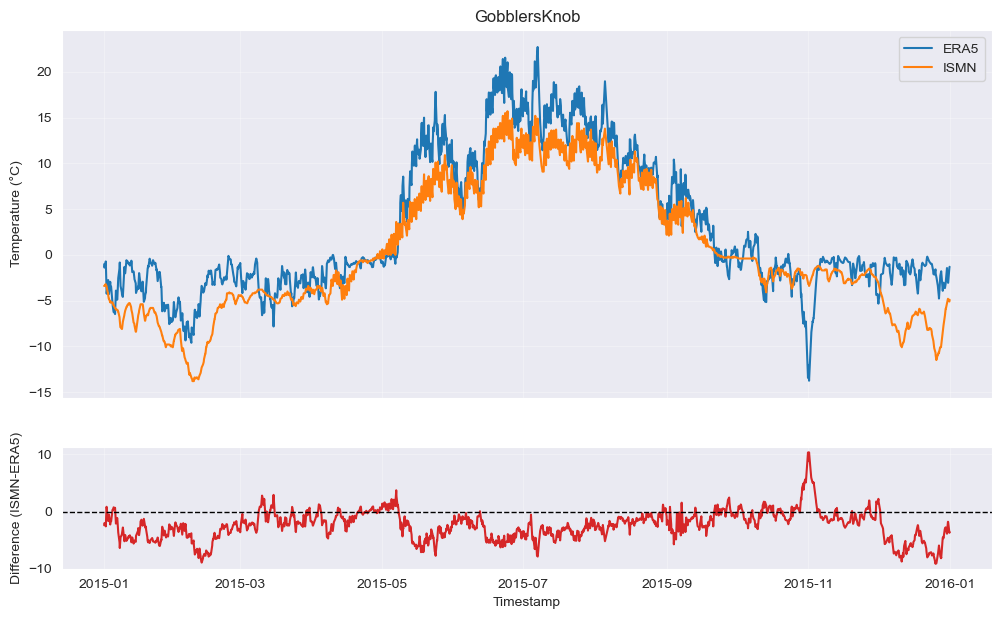

In [12]:
plot_temp_differences(gobblers_knob_era5_df, StationName.GOBBLERS_KNOB, start_date, end_date)

### 2.4 Nenana

In [13]:
_, nenana_era5_df = combine_dfs.main(StationName.NENANA, c.CLEANED_DATA_PATH)
nenana_era5_df = nenana_era5_df.dropna()

create_cm_df(nenana_era5_df, c.CLASSES)

,frozen,transition,thawed
frozen,7288,566,18
transition,2110,1070,1110
thawed,140,180,8857


<Axes: title={'center': 'Nenana'}, xlabel='Timestamp', ylabel='ERA5 stl1 (°C)'>

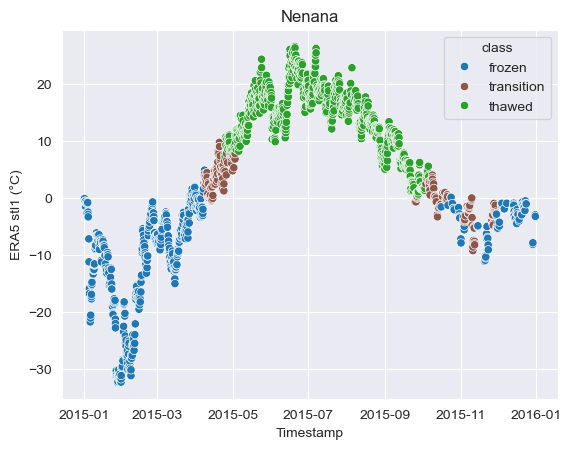

In [14]:
plot_temp_labels(nenana_era5_df, StationName.NENANA, start_date, end_date)

(<Axes: title={'center': 'Nenana'}, ylabel='Temperature (°C)'>,
 <Axes: xlabel='Timestamp', ylabel='Difference (ISMN-ERA5)'>)

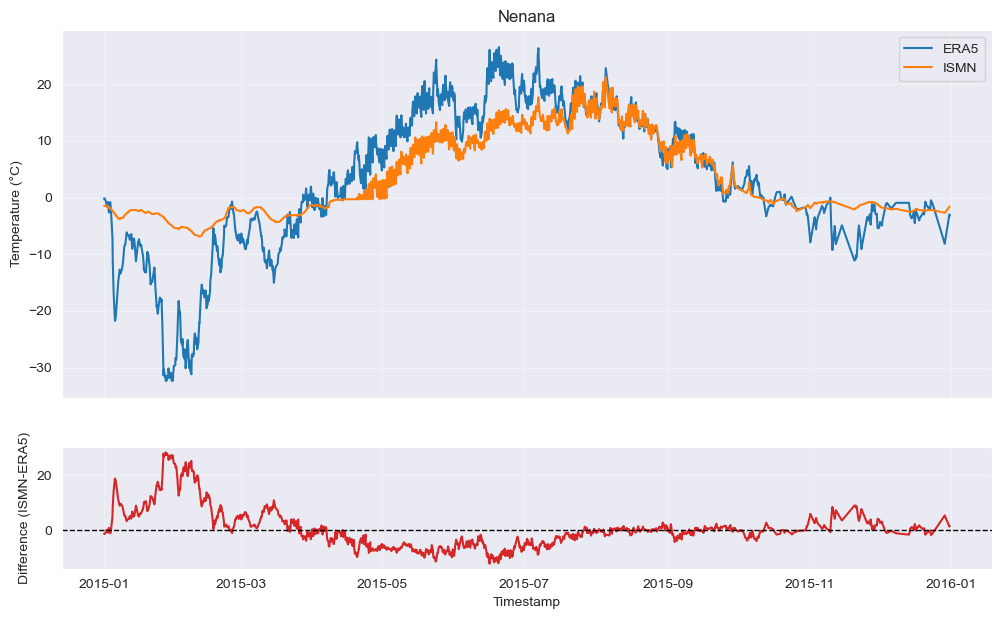

In [15]:
plot_temp_differences(nenana_era5_df, StationName.NENANA, start_date, end_date)

## 2.5 L23

In [16]:
_, L23_era5_df = combine_dfs.main(StationName.L23, c.CLEANED_DATA_PATH)
L23_era5_df = L23_era5_df.dropna()

create_cm_df(L23_era5_df, c.CLASSES)

,frozen,transition,thawed
frozen,1312,0,0
transition,529,18,0
thawed,269,236,1624


<Axes: title={'center': 'L23'}, xlabel='Timestamp', ylabel='ERA5 stl1 (°C)'>

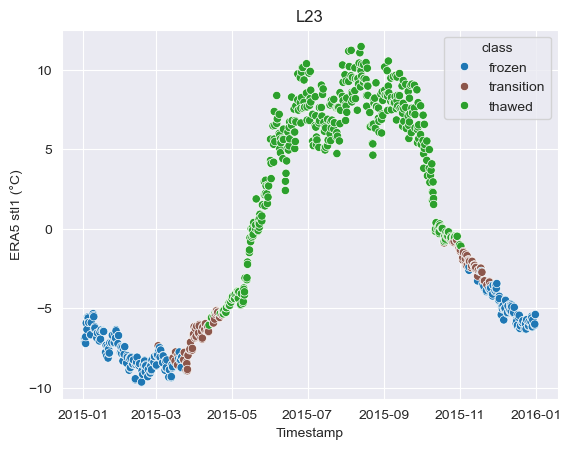

In [17]:
plot_temp_labels(L23_era5_df, StationName.L23, start_date, end_date)

(<Axes: title={'center': 'L23'}, ylabel='Temperature (°C)'>,
 <Axes: xlabel='Timestamp', ylabel='Difference (ISMN-ERA5)'>)

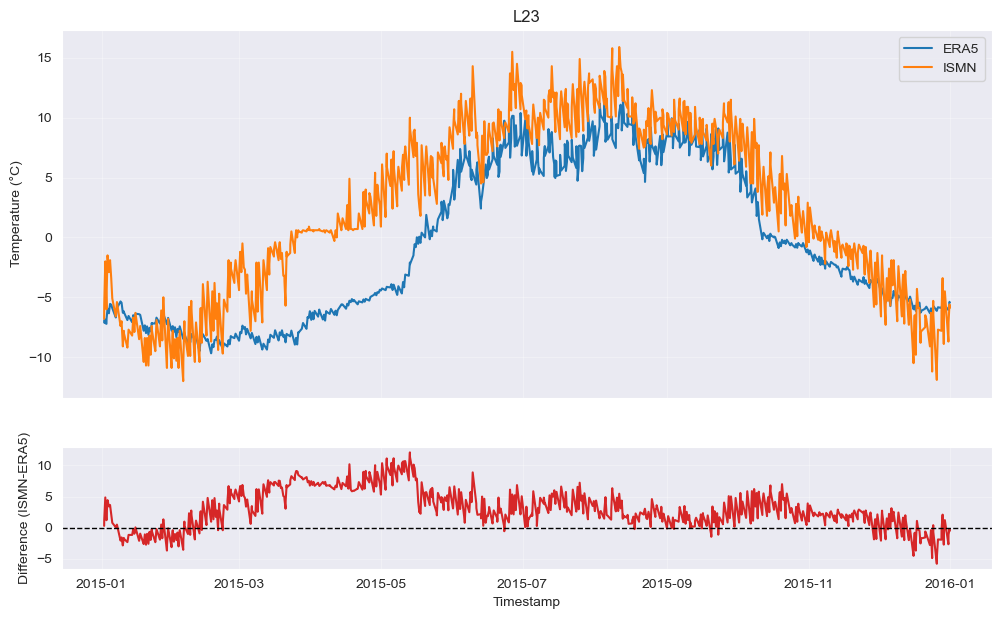

In [18]:
plot_temp_differences(L23_era5_df, StationName.L23, start_date, end_date)

### 2.6 L38

In [19]:
_, L38_era5_df = combine_dfs.main(StationName.L38, c.CLEANED_DATA_PATH)
L38_era5_df = L38_era5_df.dropna()

create_cm_df(L38_era5_df, c.CLASSES)

,frozen,transition,thawed
frozen,1051,0,0
transition,461,13,0
thawed,333,279,1647


<Axes: title={'center': 'L38'}, xlabel='Timestamp', ylabel='ERA5 stl1 (°C)'>

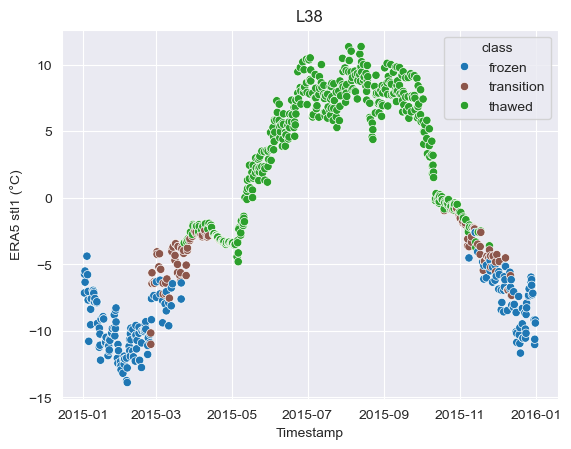

In [20]:
plot_temp_labels(L38_era5_df, StationName.L38, start_date, end_date)

(<Axes: title={'center': 'L38'}, ylabel='Temperature (°C)'>,
 <Axes: xlabel='Timestamp', ylabel='Difference (ISMN-ERA5)'>)

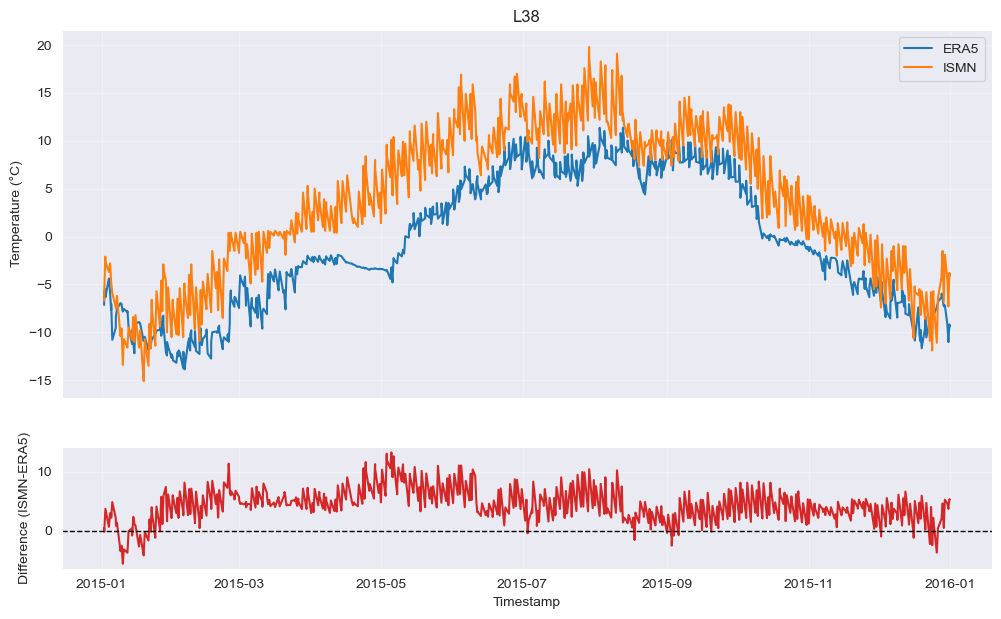

In [21]:
plot_temp_differences(L38_era5_df, StationName.L38, start_date, end_date)

## 2.7 NST-07

In [4]:
_, NST_07_era5_df = combine_dfs.main(StationName.NST_07, c.CLEANED_DATA_PATH)
NST_07_era5_df = NST_07_era5_df.dropna()

create_cm_df(NST_07_era5_df, c.CLASSES)

,frozen,transition,thawed
frozen,1233,0,0
transition,579,261,22
thawed,89,232,3053


<Axes: title={'center': 'NST-07'}, xlabel='Timestamp', ylabel='ERA5 stl1 (°C)'>

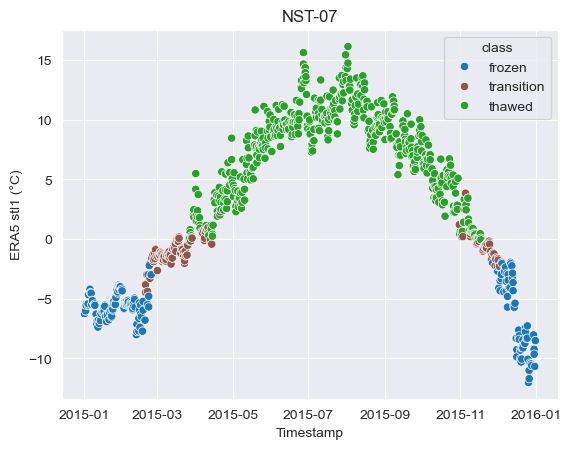

In [5]:
plot_temp_labels(NST_07_era5_df, StationName.NST_07, start_date, end_date)

(<Axes: title={'center': 'NST-07'}, ylabel='Temperature (°C)'>,
 <Axes: xlabel='Timestamp', ylabel='Difference (ISMN-ERA5)'>)

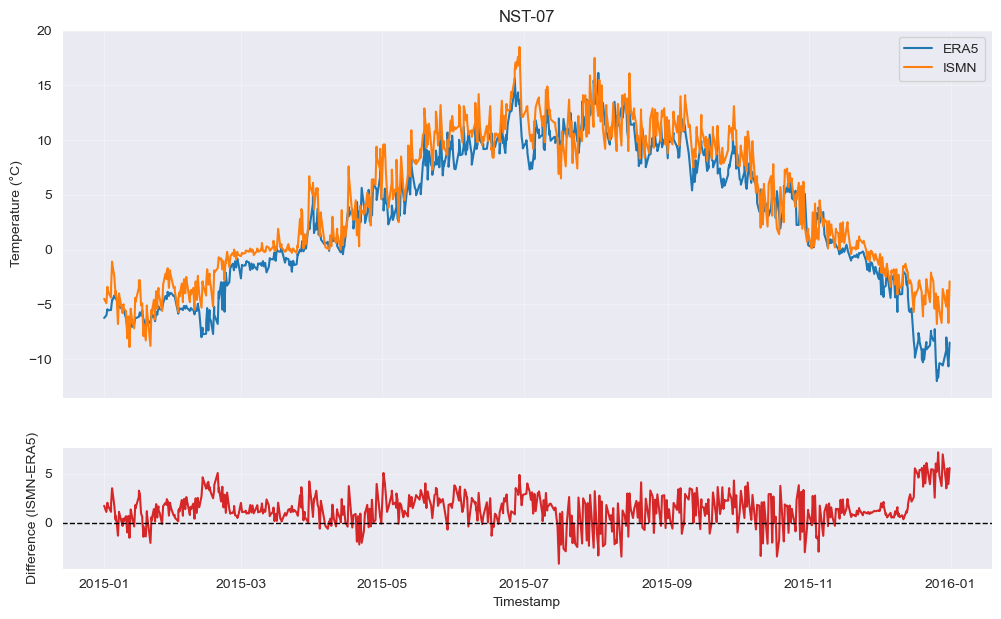

In [6]:
plot_temp_differences(NST_07_era5_df, StationName.NST_07, start_date, end_date)

### 2.8 NST-09

In [7]:
_, NST_09_era5_df = combine_dfs.main(StationName.NST_09, c.CLEANED_DATA_PATH)
NST_09_era5_df = NST_09_era5_df.dropna()

create_cm_df(NST_09_era5_df, c.CLASSES)

,frozen,transition,thawed
frozen,1379,5,0
transition,600,144,5
thawed,171,359,2960


<Axes: title={'center': 'NST-09'}, xlabel='Timestamp', ylabel='ERA5 stl1 (°C)'>

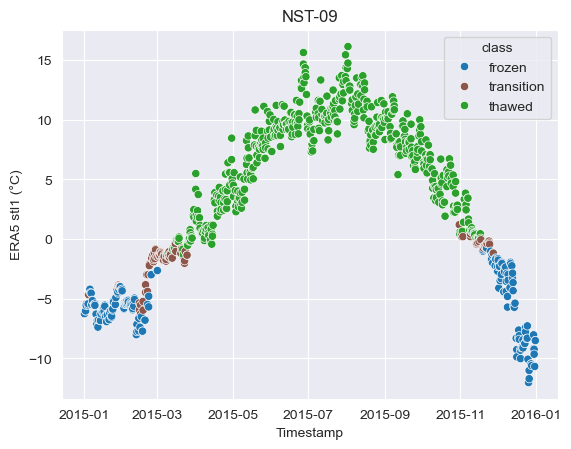

In [14]:
plot_temp_labels(NST_09_era5_df, StationName.NST_09, start_date, end_date)

(<Axes: title={'center': 'NST-09'}, ylabel='Temperature (°C)'>,
 <Axes: xlabel='Timestamp', ylabel='Difference (ISMN-ERA5)'>)

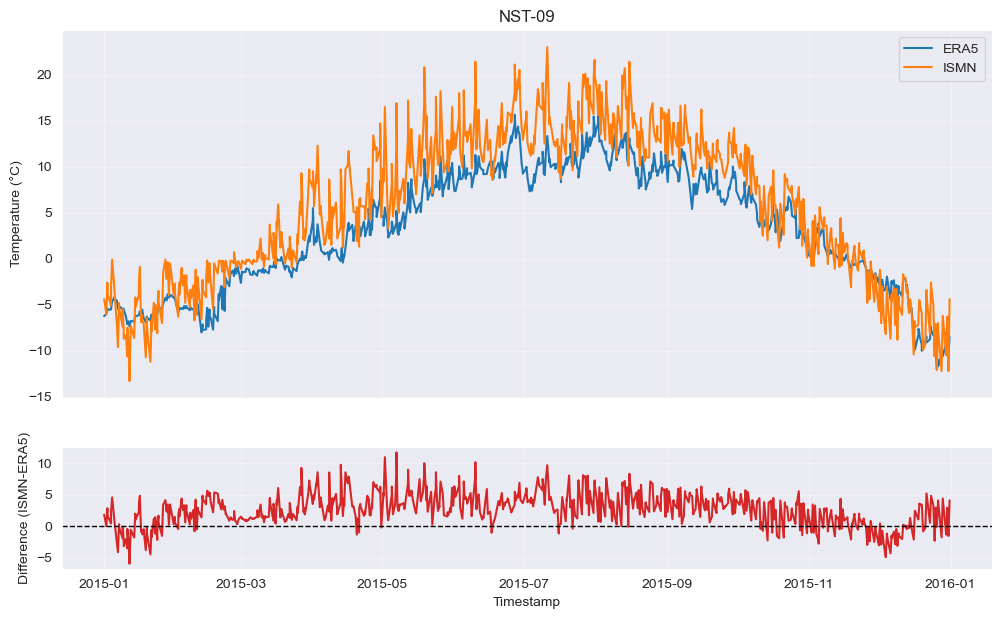

In [9]:
plot_temp_differences(NST_09_era5_df, StationName.NST_09, start_date, end_date)

### 2.9 SOD012

In [10]:
_, SOD012_era5_df = combine_dfs.main(StationName.SOD012, c.CLEANED_DATA_PATH)
SOD012_era5_df = SOD012_era5_df.dropna()

create_cm_df(SOD012_era5_df, c.CLASSES)

,frozen,transition,thawed
frozen,3621,739,0
transition,6675,3747,507
thawed,483,579,10884


<Axes: title={'center': 'SOD012'}, xlabel='Timestamp', ylabel='ERA5 stl1 (°C)'>

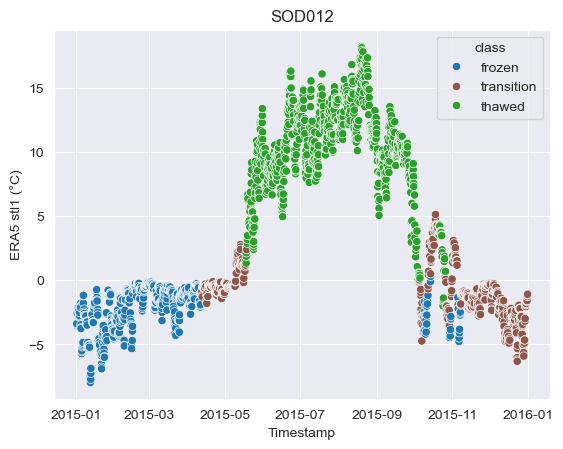

In [13]:
plot_temp_labels(SOD012_era5_df, StationName.SOD012, start_date, end_date)

(<Axes: title={'center': 'SOD012'}, ylabel='Temperature (°C)'>,
 <Axes: xlabel='Timestamp', ylabel='Difference (ISMN-ERA5)'>)

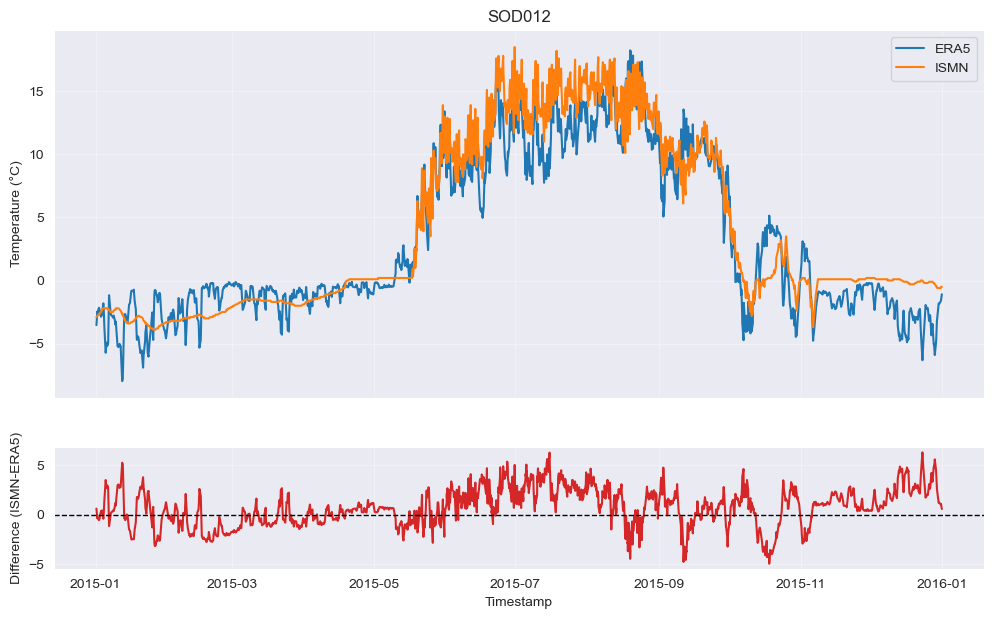

In [12]:
plot_temp_differences(SOD012_era5_df, StationName.SOD012, start_date, end_date)

### 2.10 SOD103

In [15]:
_, SOD103_era5_df = combine_dfs.main(StationName.SOD103, c.CLEANED_DATA_PATH)
SOD103_era5_df = SOD103_era5_df.dropna()

create_cm_df(SOD103_era5_df, c.CLASSES)

,frozen,transition,thawed
frozen,471,2,0
transition,7955,3124,17
thawed,2100,1860,11221


<Axes: title={'center': 'SOD103'}, xlabel='Timestamp', ylabel='ERA5 stl1 (°C)'>

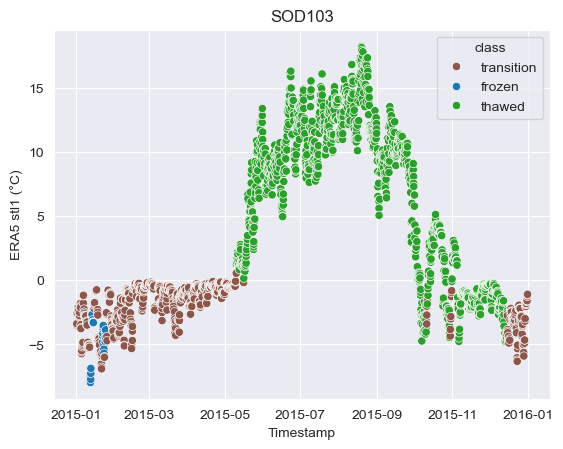

In [16]:
plot_temp_labels(SOD103_era5_df, StationName.SOD103, start_date, end_date)

(<Axes: title={'center': 'SOD103'}, ylabel='Temperature (°C)'>,
 <Axes: xlabel='Timestamp', ylabel='Difference (ISMN-ERA5)'>)

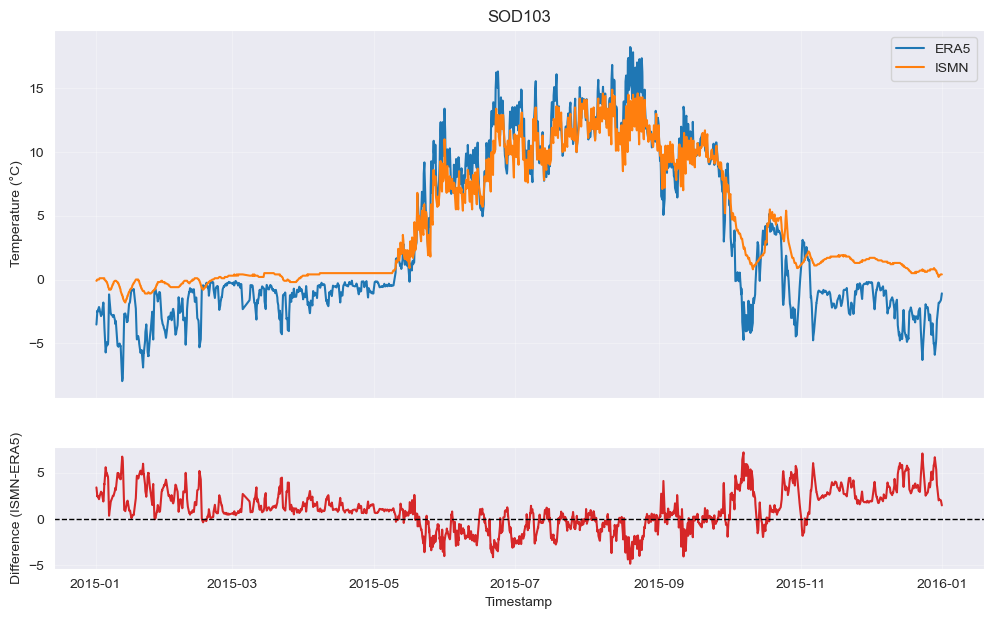

In [17]:
plot_temp_differences(SOD103_era5_df, StationName.SOD103, start_date, end_date)

## Conclusions

Overall, ERA5 did not align with the ISMN stations in predicting transition states in the soil (between -1 and 1 &deg;C). It's only decent performance was for Gobbler's Knob. This appears to be due to large differences in the measured temperatures between the two methods, with differences reaching up to 20 &deg;C. In constrast, agreement is better for the frozen and thawed states since their definitions are more forgiving than the transition state.

The plots indicate that taking a single point measurement to compare against a large area measurement is not the most sound approach.